# Trabajo Tema 4

Modelos de clasificación y clustering

Para la nota se tendrá en cuenta principalmente (80% de nota):
+ Comentarios de línea: La tarea básicamente es copiar código que ya existe en un libro o que os de una IA. Pero debéis entenderlo, explicando qué hace mediante comentarios.
+ Análisis de los resultados obtenidos en celdas Markdown.


# Parte 1: Clustering (6 puntos)

Esta parte trata de replicar y analizar los ejemplos resueltos del libro en PDF que está presente en el repositorio de GitHub

https://github.com/rpastorvargas/IntroductionToMachineLearningForSecurityPros

El código se proporciona (actualizado a Python 3, ya que el libro es antiguo) en el mismo repositorio, dentro del __directorio clustering_example__. 

El código está en archivos Python independientes, pero debéis entregar un Notebook donde se incluyan código, comentarios de línea y análisis/comparación de resultados en formato Markdown.

Como comentarios de análisis se deben indicar los resultados obtenidos en cada caso (K-Means y DBSCAN ) y compararlos con los correspondientes del libro. Es importante tener en cuenta que los resultados mostrados en el libro se corresponden con un subconjunto de los datos incluidos en el repositorio GitHub, por lo cual los resultados serán diferentes. 

El análisis y comparación se debe realizar de forma cualitativa para determinar si son coherentes y compatibles, fijandose más en los porcentajes en lugar de las cantidades absolutas.

También es importante repetir, al menos un par de veces, las ejecuciones de entrenamiento o ajuste (no las de vectorización o preparación de datos) para ver cómo afecta la aleatoriedad de los algoritmos y observar si hay algún cambio en los resultados.

## 1.1. CLUSTERING CON K-MEANS

El ejemplo comienza en página 23, "Cluster analysis with K-Means".

Debéis:
1. Copiar el código de cada archivo en su celda correspondiente. 
2. Analizar el código, entenderlo y __poner comentarios de línea__ explicando qué hace cada parte.
3. Ejecutar cada parte del código
4. Comentar el resultado obtenido y comparar los resultados con los del libro en celda Markdown.

Los archivos Python facilitados están construidos para ser ejecutados desde el terminal, pasando datos por parámetros. Debéis modificar y limpiar (lo que sobre) para que se ejecuten directamente desde el Notebook sin necesidad de recibir parámetros.

### Step 1: Vectorización y normalización

In [1]:
# Importamos librerías estándar para trabajar con archivos, rutas, expresiones regulares,
# compresión zip, direcciones IP y estructuras binarias.
import os
import re
import zipfile
import socket
import struct
import urllib.request
from pathlib import Path
from collections import Counter

# Importamos librerías científicas y de machine learning.
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import pairwise_distances, pairwise_distances_chunked
from sklearn.metrics import silhouette_samples, silhouette_score

# Definimos constantes con la URL del repositorio y las rutas locales que usaremos.
REPO_ZIP_URL = "https://github.com/rpastorvargas/IntroductionToMachineLearningForSecurityPros/archive/refs/heads/master.zip"
WORK_DIR = Path("tema4_data")
ZIP_PATH = WORK_DIR / "repo.zip"
REPO_DIR = WORK_DIR / "IntroductionToMachineLearningForSecurityPros-master"
DATA_DIR = REPO_DIR / "clustering_example" / "data" / "www.secrepo.com" / "self.logs"
H5_PATH = Path("secrepo.h5")

# Esta expresión regular extrae de cada línea del log tres campos: IP, método HTTP y código de respuesta.
LOG_REGEX = re.compile(r'(\S+)\s\S+\s\S+\s\[[^\]]+\]\s"(\S*)\s[^"]*"\s(\d+)')


def descargar_datos_si_hace_falta():
    """Descarga el repositorio si no está ya en local y comprueba que existe la carpeta de logs."""
    WORK_DIR.mkdir(exist_ok=True)  # Creamos la carpeta de trabajo si aún no existe.

    if DATA_DIR.exists():
        print(f"Datos encontrados en: {DATA_DIR}")
        return

    print("No se han encontrado los logs. Descargando el repositorio de GitHub...")
    try:
        urllib.request.urlretrieve(REPO_ZIP_URL, ZIP_PATH)  # Descargamos el zip completo del repositorio.
    except Exception as e:
        raise RuntimeError(
            "No se han podido descargar los datos automáticamente. "
            "Solución: descarga el repositorio de GitHub indicado en el enunciado, "
            "descomprímelo en la carpeta tema4_data y vuelve a ejecutar la celda."
        ) from e

    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(WORK_DIR)  # Descomprimimos el zip dentro de la carpeta de trabajo.

    if not DATA_DIR.exists():
        raise FileNotFoundError(f"No se encontró la carpeta esperada de logs: {DATA_DIR}")

    print(f"Datos descargados y preparados en: {DATA_DIR}")


def ip2int(addr):
    """Convierte una IP en formato texto, por ejemplo 192.168.1.1, a un entero."""
    return struct.unpack("!I", socket.inet_aton(addr))[0]


def int2ip(addr):
    """Convierte una IP guardada como entero de nuevo al formato legible con puntos."""
    return socket.inet_ntoa(struct.pack("!I", int(addr)))


def get_prevectors(data_path=DATA_DIR, max_ips=10000):
    """Lee los logs y cuenta, para cada IP, métodos HTTP y códigos de respuesta."""
    # Añadimos primero algunas IP concretas que aparecen en el ejemplo del libro.
    prevectors = {
        ip2int("192.187.126.162"): {"requests": {}, "responses": {}},
        ip2int("49.50.76.8"): {"requests": {}, "responses": {}},
        ip2int("70.32.104.50"): {"requests": {}, "responses": {}},
    }

    # Recorremos cada archivo de log incluido en la carpeta.
    for path in sorted(os.listdir(data_path)):
        full_path = Path(data_path) / path
        if not full_path.is_file():
            continue

        # Abrimos con errors="ignore" para evitar que una línea con codificación rara corte el proceso.
        with open(full_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                # Intentamos extraer IP, tipo de petición y código HTTP con la expresión regular.
                match = LOG_REGEX.findall(line)
                if not match:
                    continue

                ip, request_type, response_code = match[0]
                ip = ip2int(ip)
                response_code = int(response_code)

                # Limitamos el número de IPs para mantener el ejemplo manejable.
                if ip not in prevectors:
                    if len(prevectors) >= max_ips:
                        continue
                    prevectors[ip] = {"requests": {}, "responses": {}}

                # Contamos cuántas veces aparece cada método HTTP para esta IP.
                prevectors[ip]["requests"][request_type] = prevectors[ip]["requests"].get(request_type, 0) + 1

                # Contamos cuántas veces aparece cada código de respuesta para esta IP.
                prevectors[ip]["responses"][response_code] = prevectors[ip]["responses"].get(response_code, 0) + 1

    return prevectors


def convert_prevectors_to_vectors(prevectors):
    """Convierte los contadores por IP en una matriz numérica apta para clustering."""
    # Columnas dedicadas a métodos HTTP.
    request_types = ["GET", "POST", "HEAD", "OPTIONS", "PUT", "TRACE"]

    # Columnas dedicadas a códigos HTTP frecuentes en el ejemplo.
    response_codes = [200, 404, 403, 304, 301, 206, 418, 416, 400, 405, 503, 500]

    # Creamos una matriz de ceros: una fila por IP y una columna por característica.
    vectors = np.zeros((len(prevectors), len(request_types) + len(response_codes)), dtype=np.float32)
    ips = []

    # Rellenamos la matriz con los conteos observados en los logs.
    for index, (ip, values) in enumerate(prevectors.items()):
        ips.append(ip)

        for ri, request in enumerate(request_types):
            if request in values["requests"]:
                vectors[index, ri] = values["requests"][request]

        for ri, response in enumerate(response_codes):
            if response in values["responses"]:
                vectors[index, len(request_types) + ri] = values["responses"][response]

    return np.array(ips), vectors


# Ejecutamos la descarga/preparación de los datos.
descargar_datos_si_hace_falta()

# Construimos los prevectores a partir de los logs.
prevectors = get_prevectors()

# Convertimos los prevectores en una matriz numérica.
ips, vectors = convert_prevectors_to_vectors(prevectors)

# Normalizamos cada fila para que el clustering dependa más del patrón de comportamiento
# que del volumen absoluto de peticiones de cada IP.
vectors = normalize(vectors)

# Guardamos los datos en HDF5, igual que en el ejemplo original del libro/repositorio.
with h5py.File(H5_PATH, "w") as f:
    f.create_dataset("vectors", shape=vectors.shape, data=vectors)
    f.create_dataset("cluster", shape=(vectors.shape[0],), data=np.zeros((vectors.shape[0],), dtype=np.int32))
    f.create_dataset("notes", shape=(vectors.shape[0],), data=np.array(ips))

print("Vectorización terminada")
print("Archivo generado:", H5_PATH)
print("Forma de la matriz de vectores:", vectors.shape)
print("Primeras IPs:", [int2ip(ip) for ip in ips[:5]])

Datos encontrados en: tema4_data\IntroductionToMachineLearningForSecurityPros-master\clustering_example\data\www.secrepo.com\self.logs
Vectorización terminada
Archivo generado: secrepo.h5
Forma de la matriz de vectores: (10000, 18)
Primeras IPs: ['192.187.126.162', '49.50.76.8', '70.32.104.50', '173.173.123.43', '46.109.67.155']


#### Comentarios

En esta primera fase se transforman los logs de acceso web en una matriz numérica. Cada fila representa una IP y cada columna representa un tipo de petición HTTP o un código de respuesta HTTP. Después se normalizan los vectores para que el algoritmo compare patrones de comportamiento y no únicamente cantidades absolutas.

Esto es coherente con el enfoque del libro: antes de aplicar K-Means o DBSCAN se necesita convertir información textual de logs en características numéricas. Los resultados pueden cambiar respecto al libro porque el repositorio contiene más datos que el subconjunto usado en el texto, por lo que conviene comparar porcentajes y estructura general, no cantidades exactas.

### Step 2: Visualización de PCA

Forma tras PCA: (10000, 3)
Varianza explicada por cada componente: [0.46964398 0.2219374  0.1216111 ]
Varianza explicada acumulada: 0.8131925


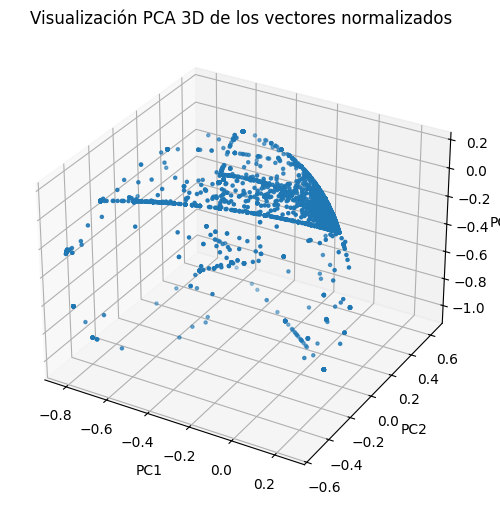

In [2]:
# Cargamos la matriz vectorizada desde el archivo HDF5 creado en el paso anterior.
with h5py.File(H5_PATH, "r") as f:
    vectors = f["vectors"][:]

# PCA reduce las 18 características originales a 3 componentes principales.
# Esto permite representar los puntos en 3D sin perder demasiada información global.
pca = PCA(n_components=3)
projected_vectors = pca.fit_transform(vectors)

# Mostramos la forma de los datos proyectados para comprobar que ahora tienen 3 columnas.
print("Forma tras PCA:", projected_vectors.shape)
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Dibujamos una nube de puntos 3D con Matplotlib.
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(projected_vectors[:, 0], projected_vectors[:, 1], projected_vectors[:, 2], s=5)
ax.set_title("Visualización PCA 3D de los vectores normalizados")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

#### Comentarios

PCA no crea clústeres; solo reduce la dimensionalidad para visualizar mejor la nube de datos. Si aparecen grupos separados en la gráfica, eso sugiere que puede haber patrones distintos de comportamiento entre IPs. Aun así, la decisión final no debe basarse solo en la imagen, porque al reducir de 18 dimensiones a 3 se pierde parte de la información.

La varianza explicada acumulada indica qué proporción aproximada de la información original queda representada en la visualización 3D. Cuanto mayor sea, más representativa será la gráfica.

### Step 3: First Pass Clustering with K-Means

In [3]:
# Cargamos vectores e IPs desde el HDF5.
with h5py.File(H5_PATH, "r") as f:
    vectors = f["vectors"][:]
    ips = f["notes"][:]

# Aplicamos K-Means con k=2, como primera prueba sencilla del libro.
# n_init indica cuántas inicializaciones distintas se prueban para reducir el efecto del azar.
kmeans_2 = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters_k2 = kmeans_2.fit_predict(vectors)

# Contamos cuántas muestras han caído en cada clúster.
counter_k2 = Counter(clusters_k2.tolist())
for label in sorted(counter_k2):
    print(f"Label {label} has {counter_k2[label]} samples ({counter_k2[label] / len(clusters_k2) * 100:.2f}%)")

# Guardamos un nuevo archivo HDF5 con la etiqueta de clúster asignada a cada IP.
KMEANS2_PATH = Path("secrepo_kmeans_k2.h5")
with h5py.File(KMEANS2_PATH, "w") as f:
    f.create_dataset("vectors", shape=vectors.shape, data=vectors)
    f.create_dataset("cluster", shape=(vectors.shape[0],), data=clusters_k2, dtype=np.int32)
    f.create_dataset("notes", shape=(vectors.shape[0],), data=np.array(ips))

print("Archivo con clústeres K-Means k=2:", KMEANS2_PATH)

Label 0 has 8034 samples (80.34%)
Label 1 has 1966 samples (19.66%)
Archivo con clústeres K-Means k=2: secrepo_kmeans_k2.h5


#### Comentarios

K-Means con `k=2` fuerza al algoritmo a separar todos los datos en dos grupos. Si un clúster concentra la gran mayoría de muestras y el otro es mucho más pequeño, se puede interpretar como una separación entre comportamiento mayoritario y comportamiento menos frecuente o anómalo.

Es normal que los números no coincidan exactamente con el libro, porque el libro trabaja con un subconjunto. La comparación importante es cualitativa: comprobar si también aparece una distribución desigual de clústeres y si los porcentajes tienen sentido.

#### Step 4: Validating Our Cluster Statistically

In [4]:
def stats_pairs_distances(vectors):
    """Calcula distancia mínima, máxima y media entre vectores usando bloques para ahorrar memoria."""
    gen_dist_chunks = pairwise_distances_chunked(vectors)
    first_chunk = next(gen_dist_chunks)

    low = first_chunk.min()
    high = first_chunk.max()
    acum = first_chunk.sum()
    count = first_chunk.size

    for chunk in gen_dist_chunks:
        low = min(low, chunk.min())
        high = max(high, chunk.max())
        acum += chunk.sum()
        count += chunk.size

    # Restamos la diagonal de ceros para que la media no quede artificialmente reducida.
    return low, high, acum / (count - len(vectors))


def analizar_clustering(h5_path):
    """Muestra métricas estadísticas y de calidad para un archivo HDF5 ya clusterizado."""
    with h5py.File(h5_path, "r") as f:
        vectors = f["vectors"][:]
        clusters = f["cluster"][:]

    print("Vectors shape:", vectors.shape)
    print("Minimum feature value:", vectors.min())
    print("Mean feature value:", vectors.mean())
    print("Max feature value:", vectors.max())
    print("Percentage of null values:", 100.0 * ((vectors == 0).sum() / vectors.size))
    print("")

    low, high, avg = stats_pairs_distances(vectors)
    print("Minimum distance between vectors:", low)
    print("Mean distance between vectors:", avg)
    print("Maximum distance between vectors:", high)
    print("")

    labels = sorted(set(clusters.tolist()))
    print("Number of labels:", len(labels))

    # Silhouette solo es válida si hay al menos 2 etiquetas y menos etiquetas que muestras.
    if 1 < len(labels) < len(vectors):
        silhouette_scores = silhouette_samples(vectors, clusters)
        print("Overall Silhouette Score:", silhouette_scores.mean())
    else:
        silhouette_scores = None
        print("Silhouette no calculable con este número de etiquetas.")

    centroid_distances = []
    for label in labels:
        n_vects = vectors[clusters == label, :]
        centroid = n_vects.mean(axis=0)
        centroid_distances.extend(pairwise_distances(centroid.reshape(1, -1), n_vects).tolist()[0])
        low_l, high_l, avg_l = stats_pairs_distances(n_vects) if len(n_vects) > 1 else (0, 0, 0)

        if silhouette_scores is not None:
            score_text = f"avg silhouette: {silhouette_scores[clusters == label].mean():.4f}"
        else:
            score_text = "avg silhouette: N/A"

        print(
            f"Number of items in label {label}: {n_vects.shape[0]} "
            f"({100.0 * n_vects.shape[0] / vectors.shape[0]:.2f}%) "
            f"(avg dist: {avg_l:.4f}) ({score_text})"
        )

    centroid_distances = np.array(centroid_distances)
    print("")
    print("Minimum label centroid distance:", centroid_distances.min())
    print("Mean label centroid distance:", centroid_distances.mean())
    print("Max label centroid distance:", centroid_distances.max())

# Analizamos estadísticamente el resultado de K-Means con k=2.
analizar_clustering(KMEANS2_PATH)

Vectors shape: (10000, 18)
Minimum feature value: 0.0
Mean feature value: 0.082806975
Max feature value: 0.8838835
Percentage of null values: 85.83611111111111

Minimum distance between vectors: 0.0
Mean distance between vectors: 0.41717616
Maximum distance between vectors: 1.4142137

Number of labels: 2
Overall Silhouette Score: 0.63882446
Number of items in label 0: 8034 (80.34%) (avg dist: 0.1897) (avg silhouette: 0.7715)
Number of items in label 1: 1966 (19.66%) (avg dist: 0.7384) (avg silhouette: 0.0966)

Minimum label centroid distance: 0.026114413514733315
Mean label centroid distance: 0.22613847047649324
Max label centroid distance: 1.2852680683135986


#### Comentarios

La validación estadística permite medir si los clústeres están bien separados. La métrica más útil aquí es el `Silhouette Score`: valores cercanos a 1 indican separación clara, valores cercanos a 0 indican solapamiento y valores negativos indican posibles asignaciones incorrectas.

También se muestran distancias internas por clúster. Si un clúster tiene distancia media baja, sus elementos son parecidos entre sí. Si tiene distancia alta, el grupo puede ser demasiado amplio o poco homogéneo.

### Step 5: Inspecting Our Clusters

In [5]:
def mostrar_ips_por_cluster(h5_path, label=None, max_por_cluster=25):
    """Imprime las IPs de cada clúster o de un clúster concreto."""
    with h5py.File(h5_path, "r") as f:
        ips = f["notes"][:]
        clusters = f["cluster"][:]

    labels = [label] if label is not None else sorted(set(clusters.tolist()))

    for cluster_id in labels:
        cluster_ips = ips[clusters == cluster_id]
        print(f"\nCluster {cluster_id} - total IPs: {len(cluster_ips)}")
        for ip in cluster_ips[:max_por_cluster]:
            print(cluster_id, int2ip(ip))
        if len(cluster_ips) > max_por_cluster:
            print(f"... ({len(cluster_ips) - max_por_cluster} IPs más no mostradas)")

# Inspeccionamos las IPs asignadas a cada clúster de K-Means k=2.
mostrar_ips_por_cluster(KMEANS2_PATH)


Cluster 0 - total IPs: 8034
0 173.173.123.43
0 46.109.67.155
0 192.227.226.2
0 23.254.136.36
0 157.55.39.210
0 157.55.39.128
0 107.77.75.17
0 166.216.165.56
0 166.216.165.85
0 199.116.169.254
0 134.134.137.73
0 134.134.139.74
0 174.103.122.67
0 89.128.18.205
0 66.87.119.77
0 66.249.69.11
0 66.249.69.239
0 189.71.228.175
0 54.161.130.203
0 69.254.155.31
0 107.77.75.34
0 66.112.31.42
0 64.53.236.187
0 108.203.150.18
0 199.16.156.125
... (8009 IPs más no mostradas)

Cluster 1 - total IPs: 1966
1 192.187.126.162
1 49.50.76.8
1 70.32.104.50
1 104.130.161.38
1 104.130.161.37
1 104.130.160.87
1 104.130.20.53
1 71.164.230.33
1 50.97.94.48
1 166.216.157.15
1 54.80.124.105
1 173.59.251.17
1 73.26.128.175
1 12.207.17.3
1 213.130.111.50
1 199.203.134.91
1 194.203.214.50
1 68.180.228.109
1 109.67.37.159
1 88.150.136.178
1 183.207.228.14
1 54.71.238.52
1 172.56.3.149
1 108.48.71.29
1 78.245.91.140
... (1941 IPs más no mostradas)


#### Comentarios

La inspección de IPs ayuda a pasar de una métrica abstracta a una interpretación más práctica. Si las IPs de un clúster pequeño tienen patrones muy distintos al grupo principal, pueden representar comportamientos raros o potencialmente sospechosos.

Como el dataset usado aquí puede ser mayor que el del libro, no se espera que aparezcan exactamente las mismas IPs ni el mismo número de muestras. Lo importante es comprobar si el clúster pequeño sigue actuando como grupo diferenciado.

### Step 6: Modifying K to Optimize Cluster Results

Volver a aplicar el algoritmo cambiando el valor de k. Copia de nuevo el código. 

In [6]:
# Probamos K-Means con más clústeres para comprobar si k=2 era demasiado simple.
# k=5 suele permitir separar mejor comportamientos distintos sin fragmentar en exceso.
K_OPT = 5

with h5py.File(H5_PATH, "r") as f:
    vectors = f["vectors"][:]
    ips = f["notes"][:]

kmeans_5 = KMeans(n_clusters=K_OPT, n_init=10, random_state=42)
clusters_k5 = kmeans_5.fit_predict(vectors)

counter_k5 = Counter(clusters_k5.tolist())
for label in sorted(counter_k5):
    print(f"Label {label} has {counter_k5[label]} samples ({counter_k5[label] / len(clusters_k5) * 100:.2f}%)")

KMEANS5_PATH = Path(f"secrepo_kmeans_k{K_OPT}.h5")
with h5py.File(KMEANS5_PATH, "w") as f:
    f.create_dataset("vectors", shape=vectors.shape, data=vectors)
    f.create_dataset("cluster", shape=(vectors.shape[0],), data=clusters_k5, dtype=np.int32)
    f.create_dataset("notes", shape=(vectors.shape[0],), data=np.array(ips))

print("Archivo con clústeres K-Means k=5:", KMEANS5_PATH)

# Repetimos varias ejecuciones con n_init=1 para observar el efecto de la aleatoriedad.
print("\nRepeticiones con distintas semillas para observar aleatoriedad:")
for seed in [0, 1, 2]:
    model = KMeans(n_clusters=K_OPT, n_init=1, random_state=seed)
    labels = model.fit_predict(vectors)
    counts = Counter(labels.tolist())
    print(f"Seed {seed} -> inercia={model.inertia_:.4f}, tamaños={dict(sorted(counts.items()))}")

Label 0 has 7464 samples (74.64%)
Label 1 has 1090 samples (10.90%)
Label 2 has 171 samples (1.71%)
Label 3 has 411 samples (4.11%)
Label 4 has 864 samples (8.64%)
Archivo con clústeres K-Means k=5: secrepo_kmeans_k5.h5

Repeticiones con distintas semillas para observar aleatoriedad:
Seed 0 -> inercia=580.5718, tamaños={0: 7359, 1: 265, 2: 919, 3: 582, 4: 875}
Seed 1 -> inercia=560.7724, tamaños={0: 7486, 1: 1190, 2: 196, 3: 951, 4: 177}
Seed 2 -> inercia=585.3300, tamaños={0: 5983, 1: 2644, 2: 726, 3: 116, 4: 531}


#### Comentarios

Al aumentar `k`, K-Means puede representar más tipos de comportamiento. Si aparecen varios clústeres pequeños, puede significar que existen patrones minoritarios que con `k=2` quedaban mezclados dentro de un grupo más grande.

Las repeticiones con distintas semillas muestran el papel de la aleatoriedad en K-Means. Si la inercia y los tamaños de los clústeres cambian poco, el resultado es bastante estable. Si cambian mucho, significa que la elección de centroides iniciales influye bastante y habría que usar más inicializaciones (`n_init`) o revisar el valor de `k`.

### Step 7: Repeating Our Inspection and Validation Procedures

In [7]:
# Repetimos la validación estadística con el nuevo valor de k.
analizar_clustering(KMEANS5_PATH)

# Repetimos también la inspección de IPs para ver qué contiene cada clúster.
mostrar_ips_por_cluster(KMEANS5_PATH, max_por_cluster=15)

Vectors shape: (10000, 18)
Minimum feature value: 0.0
Mean feature value: 0.082806975
Max feature value: 0.8838835
Percentage of null values: 85.83611111111111

Minimum distance between vectors: 0.0
Mean distance between vectors: 0.41717616
Maximum distance between vectors: 1.4142137

Number of labels: 5
Overall Silhouette Score: 0.6927333
Number of items in label 0: 7464 (74.64%) (avg dist: 0.1309) (avg silhouette: 0.7891)
Number of items in label 1: 1090 (10.90%) (avg dist: 0.3912) (avg silhouette: 0.4534)
Number of items in label 2: 171 (1.71%) (avg dist: 0.6360) (avg silhouette: 0.3763)
Number of items in label 3: 411 (4.11%) (avg dist: 0.6444) (avg silhouette: 0.1636)
Number of items in label 4: 864 (8.64%) (avg dist: 0.3261) (avg silhouette: 0.4762)

Minimum label centroid distance: 0.0137443533167243
Mean label centroid distance: 0.16563024193337186
Max label centroid distance: 1.3057960271835327

Cluster 0 - total IPs: 7464
0 173.173.123.43
0 192.227.226.2
0 23.254.136.36
0 157

#### Comentarios

Esta validación permite comparar `k=2` frente a `k=5`. Si el Silhouette Score mejora y las distancias internas bajan, el nuevo valor de `k` describe mejor la estructura de los datos. Si el Silhouette empeora mucho, puede indicar que se están creando grupos artificiales.

La elección óptima no depende solo de una métrica: también importa que los grupos sean interpretables. En seguridad, un clúster pequeño puede ser interesante aunque empeore ligeramente una métrica global, porque podría aislar tráfico poco habitual.

### SELECCIÓN OPTIMA DE K MEDIANTE EL MÉTODO DEL CODO

Aplica K-Means en un bucle, desde k=2 a k=25, calculando la Inercia (WCSS) y graficandola (eje x es el valor de K, eje Y es la inercia)

k= 2 -> inercia=1017.5865
k= 3 -> inercia=748.7946
k= 4 -> inercia=617.6598
k= 5 -> inercia=511.5810
k= 6 -> inercia=438.3875
k= 7 -> inercia=342.2817
k= 8 -> inercia=285.8144
k= 9 -> inercia=248.0318
k=10 -> inercia=210.6283
k=11 -> inercia=188.0901
k=12 -> inercia=164.7822
k=13 -> inercia=149.3464
k=14 -> inercia=137.9660
k=15 -> inercia=128.5370
k=16 -> inercia=119.1548
k=17 -> inercia=112.2856
k=18 -> inercia=105.1920
k=19 -> inercia=96.5081
k=20 -> inercia=91.4375
k=21 -> inercia=85.8621
k=22 -> inercia=78.2319
k=23 -> inercia=73.7507
k=24 -> inercia=69.0051
k=25 -> inercia=65.8347


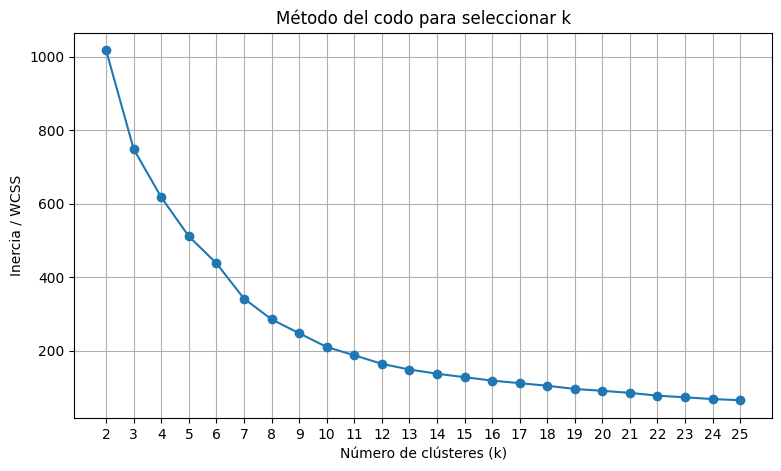

In [8]:
# Cargamos los vectores normalizados.
with h5py.File(H5_PATH, "r") as f:
    vectors = f["vectors"][:]

# Probamos valores de k desde 2 hasta 25.
k_values = range(2, 26)
inertias = []

for k in k_values:
    # Entrenamos K-Means para cada valor de k.
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(vectors)

    # La inercia mide la suma de distancias cuadradas dentro de los clústeres.
    inertias.append(model.inertia_)
    print(f"k={k:2d} -> inercia={model.inertia_:.4f}")

# Graficamos el método del codo.
plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Método del codo para seleccionar k")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia / WCSS")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

---
## 1.2. CLUSTERING CON DBSCAN

El ejemplo comienza en página 31, "Cluster analysis with DBSCAN".

Como bien dice el libro, podemos saltarnos step 1 y 2 ya que los datos están vectorizados y normalizados en secrepo.h5. Además no es necesario volver a graficar.

Pasamos directamente a aplicar el algoritmo.

Debéis:
1. Copiar el código de cada archivo en su celda correspondiente.
2. Analizar el código, entenderlo y __poner comentarios de línea__ explicando qué hace cada parte.
3. Ejecutar cada parte del código
4. Comentar el resultado obtenido y comparar los resultados con los del libro en celda Markdown.

### Ejecución para hiperparámetros Eps=0.5 y MinPts=5

Meter ejecución del algoritmo y la inspección de resultados en 2 celdas consecutivas

In [9]:
# DBSCAN no necesita indicar el número de clústeres.
# eps define el radio de vecindad y min_samples el mínimo de puntos para formar zona densa.
EPS = 0.5
MIN_SAMPLES = 5

with h5py.File(H5_PATH, "r") as f:
    vectors = f["vectors"][:]
    ips = f["notes"][:]

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
clusters_db = dbscan.fit_predict(vectors)

# En DBSCAN la etiqueta -1 representa ruido, es decir, puntos que no pertenecen a ningún clúster denso.
counter_db = Counter(clusters_db.tolist())
for label in sorted(counter_db):
    tipo = "ruido" if label == -1 else "cluster"
    print(f"Label {label} ({tipo}) has {counter_db[label]} samples ({counter_db[label] / len(clusters_db) * 100:.2f}%)")

DBSCAN_PATH = Path("secrepo_dbscan_eps05_min5.h5")
with h5py.File(DBSCAN_PATH, "w") as f:
    f.create_dataset("vectors", shape=vectors.shape, data=vectors)
    f.create_dataset("cluster", shape=(vectors.shape[0],), data=clusters_db, dtype=np.int32)
    f.create_dataset("notes", shape=(vectors.shape[0],), data=np.array(ips))

print("Archivo con clústeres DBSCAN:", DBSCAN_PATH)

Label -1 (ruido) has 12 samples (0.12%)
Label 0 (cluster) has 9967 samples (99.67%)
Label 1 (cluster) has 9 samples (0.09%)
Label 2 (cluster) has 6 samples (0.06%)
Label 3 (cluster) has 6 samples (0.06%)
Archivo con clústeres DBSCAN: secrepo_dbscan_eps05_min5.h5


In [10]:
# Analizamos estadísticamente los clústeres generados por DBSCAN.
analizar_clustering(DBSCAN_PATH)

# Mostramos algunas IPs de cada etiqueta, incluyendo ruido (-1) si existe.
mostrar_ips_por_cluster(DBSCAN_PATH, max_por_cluster=15)

Vectors shape: (10000, 18)
Minimum feature value: 0.0
Mean feature value: 0.082806975
Max feature value: 0.8838835
Percentage of null values: 85.83611111111111

Minimum distance between vectors: 0.0
Mean distance between vectors: 0.41717616
Maximum distance between vectors: 1.4142137

Number of labels: 5
Overall Silhouette Score: 0.6201337
Number of items in label -1: 12 (0.12%) (avg dist: 1.2032) (avg silhouette: -0.0669)
Number of items in label 0: 9967 (99.67%) (avg dist: 0.4119) (avg silhouette: 0.6202)
Number of items in label 1: 9 (0.09%) (avg dist: 0.0000) (avg silhouette: 1.0000)
Number of items in label 2: 6 (0.06%) (avg dist: 0.0000) (avg silhouette: 1.0000)
Number of items in label 3: 6 (0.06%) (avg dist: 0.0000) (avg silhouette: 1.0000)

Minimum label centroid distance: 0.0
Mean label centroid distance: 0.3110183618104632
Max label centroid distance: 1.3136245012283325

Cluster -1 - total IPs: 12
-1 54.80.124.105
-1 62.210.141.227
-1 117.15.162.240
-1 98.126.142.26
-1 117.1

#### Comentarios

DBSCAN funciona de forma distinta a K-Means: no obliga a que todos los puntos pertenezcan a un clúster y puede marcar algunos como ruido (`-1`). Esto es especialmente útil en seguridad, porque los puntos aislados pueden representar comportamientos anómalos.

Con `eps=0.5` y `min_samples=5`, si aparece mucho ruido, el radio puede ser demasiado pequeño o el mínimo de puntos demasiado exigente. Si aparece un único clúster gigante y casi nada de ruido, el radio puede ser demasiado grande. La comparación con el libro debe hacerse en términos cualitativos: presencia de ruido, número de grupos densos y porcentajes aproximados.

### Pruebas de otros hiperparámetros

Aquí no seguimos el libro. Debéis pobrar varios hiperparámetros y decidir cual se ajusta mejor. Es decir, solo quedáis en la celda de código una versión. 

Por ejemplo:
1. Eps=0.6
2. Eps=0.4

Y variar también MinPts.

In [11]:
# Probamos varias combinaciones de hiperparámetros para DBSCAN.
# El objetivo es encontrar un equilibrio entre número de clústeres, ruido y separación.
param_grid = [
    (0.3, 3), (0.3, 5),
    (0.4, 3), (0.4, 5),
    (0.5, 5), (0.6, 5),
    (0.7, 5), (0.6, 10)
]

with h5py.File(H5_PATH, "r") as f:
    vectors = f["vectors"][:]
    ips = f["notes"][:]

resultados = []

for eps, min_samples in param_grid:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(vectors)
    counts = Counter(labels.tolist())

    n_noise = counts.get(-1, 0)
    n_clusters = len([label for label in counts if label != -1])
    noise_pct = 100 * n_noise / len(labels)

    # Calculamos silhouette solo si hay al menos dos etiquetas útiles.
    unique_labels = set(labels.tolist())
    if 1 < len(unique_labels) < len(labels):
        sil = silhouette_score(vectors, labels)
    else:
        sil = np.nan

    resultados.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "noise_pct": noise_pct,
        "silhouette": sil,
        "counts": dict(sorted(counts.items()))
    })

# Mostramos una tabla resumen para decidir.
resumen = pd.DataFrame(resultados)
display(resumen[["eps", "min_samples", "n_clusters", "noise_pct", "silhouette"]])

print("Detalle de tamaños por combinación:")
for r in resultados:
    print(f"eps={r['eps']}, min_samples={r['min_samples']} -> {r['counts']}")

# Elegimos automáticamente una configuración razonable:
# 1) que tenga al menos 2 clústeres, 2) que no marque casi todo como ruido,
# 3) que maximice silhouette entre las opciones válidas.
validos = [r for r in resultados if r["n_clusters"] >= 2 and r["noise_pct"] < 80 and not np.isnan(r["silhouette"])]
if validos:
    mejor = max(validos, key=lambda r: r["silhouette"])
else:
    mejor = min(resultados, key=lambda r: abs(r["noise_pct"] - 20))

print("\nConfiguración elegida:", mejor)

# Entrenamos y guardamos el modelo DBSCAN con la configuración seleccionada.
dbscan_best = DBSCAN(eps=mejor["eps"], min_samples=mejor["min_samples"])
clusters_best = dbscan_best.fit_predict(vectors)

DBSCAN_BEST_PATH = Path("secrepo_dbscan_mejor.h5")
with h5py.File(DBSCAN_BEST_PATH, "w") as f:
    f.create_dataset("vectors", shape=vectors.shape, data=vectors)
    f.create_dataset("cluster", shape=(vectors.shape[0],), data=clusters_best, dtype=np.int32)
    f.create_dataset("notes", shape=(vectors.shape[0],), data=np.array(ips))

analizar_clustering(DBSCAN_BEST_PATH)
mostrar_ips_por_cluster(DBSCAN_BEST_PATH, max_por_cluster=10)

,eps,min_samples,n_clusters,noise_pct,silhouette
0,0.3,3,11,0.18,0.494649
1,0.3,5,10,0.24,0.516747
2,0.4,3,9,0.11,0.598687
3,0.4,5,7,0.17,0.602828
4,0.5,5,4,0.12,0.620134
5,0.6,5,4,0.10,0.622144
6,0.7,5,3,0.10,0.624031
7,0.6,10,1,0.31,0.669578


Detalle de tamaños por combinación:
eps=0.3, min_samples=3 -> {-1: 18, 0: 73, 1: 9815, 2: 21, 3: 9, 4: 8, 5: 25, 6: 6, 7: 3, 8: 13, 9: 6, 10: 3}
eps=0.3, min_samples=5 -> {-1: 24, 0: 73, 1: 9722, 2: 21, 3: 93, 4: 9, 5: 8, 6: 25, 7: 6, 8: 13, 9: 6}
eps=0.4, min_samples=3 -> {-1: 11, 0: 3, 1: 9920, 2: 21, 3: 9, 4: 8, 5: 6, 6: 3, 7: 13, 8: 6}
eps=0.4, min_samples=5 -> {-1: 17, 0: 9920, 1: 21, 2: 9, 3: 8, 4: 6, 5: 13, 6: 6}
eps=0.5, min_samples=5 -> {-1: 12, 0: 9967, 1: 9, 2: 6, 3: 6}
eps=0.6, min_samples=5 -> {-1: 10, 0: 9969, 1: 9, 2: 6, 3: 6}
eps=0.7, min_samples=5 -> {-1: 10, 0: 9975, 1: 9, 2: 6}
eps=0.6, min_samples=10 -> {-1: 31, 0: 9969}

Configuración elegida: {'eps': 0.7, 'min_samples': 5, 'n_clusters': 3, 'noise_pct': 0.1, 'silhouette': 0.6240308880805969, 'counts': {-1: 10, 0: 9975, 1: 9, 2: 6}}
Vectors shape: (10000, 18)
Minimum feature value: 0.0
Mean feature value: 0.082806975
Max feature value: 0.8838835
Percentage of null values: 85.83611111111111

Minimum distance between 

#### Comentarios

En DBSCAN, `eps` es el parámetro más sensible. Si `eps` aumenta, más puntos se consideran vecinos, por lo que normalmente disminuye el ruido y los clústeres tienden a fusionarse. Si `eps` disminuye, el algoritmo se vuelve más estricto y aumenta la cantidad de puntos marcados como ruido.

`min_samples` controla cuántos vecinos son necesarios para considerar una zona como densa. Un valor alto hace que DBSCAN sea más exigente y puede convertir más puntos en ruido. Un valor bajo permite formar clústeres más fácilmente, pero también puede aceptar grupos poco robustos.

La mejor configuración es la que mantiene una cantidad razonable de clústeres, no convierte casi todo en ruido y ofrece una separación aceptable según `silhouette`. Desde el punto de vista de seguridad, el ruido no es necesariamente malo: puede señalar IPs con comportamiento raro que merecen revisión.

---
# Parte 2: Regresión Logística (4 puntos)

En esta parte tendréis que investigar algo, no partimos de ningún libro.

El código entregado debe estar debidamente comentado, explicando qué es y qué hace cada instrucción, clase o método.

Puedes dividir en varias celdas según tu criterio.

Tareas a realizar:

1. Carga el dataset breast_cancer desde la librería sklearn.datasets.
2. Realiza una exploración inicial: ¿Cuántas muestras hay? ¿Cuántas características (features) definen cada caso? ¿están escaladas/normalizadas?
3. Divide los datos en dos conjuntos: 80% / 20%
4. Escala las características si no lo están. Debes aplicar también la transformación al conjunto de test.
5. Entrega el modelo LogisticRegression().
6. Genera y muestra la Matriz de Confusión.
7. Calcula métricas: Accuaracy_score, Precisión.
8. Analizar todos los resultados en los comentarios finales.

Número de muestras: 569
Número de características: 30
Clases: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

Primeras filas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744



Conclusión sobre escalado:
Las características NO están escaladas: tienen medias, desviaciones y rangos muy diferentes.
Tamaño entrenamiento: (455, 30)
Tamaño test: (114, 30)
Matriz de confusión:


,Predicho malignant,Predicho benign
Real malignant,41,1
Real benign,1,71


Accuracy: 0.9825
Precisión: 0.9861

Informe de clasificación:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



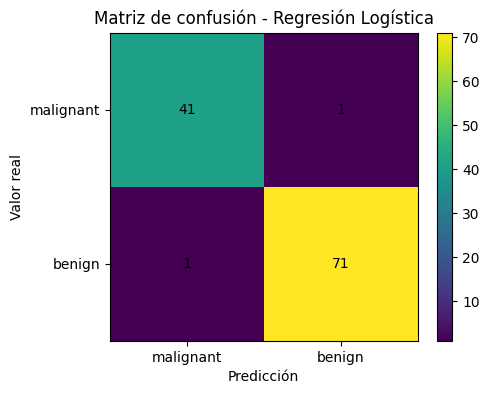

In [12]:
# Importamos las herramientas necesarias para clasificación supervisada.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report

# 1. Cargamos el dataset breast_cancer incluido en scikit-learn.
data = load_breast_cancer()
X = data.data      # Matriz de características: medidas calculadas sobre imágenes de células.
y = data.target    # Variable objetivo: clase del tumor.

# Convertimos a DataFrame para explorar más cómodamente las columnas.
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

# 2. Exploración inicial del dataset.
print("Número de muestras:", X.shape[0])
print("Número de características:", X.shape[1])
print("Clases:", dict(zip(data.target_names, np.bincount(y))))
print("\nPrimeras filas:")
display(df.head())

# Comprobamos si las variables parecen escaladas mirando medias y desviaciones típicas.
exploracion = df.drop(columns="target").describe().T[["mean", "std", "min", "max"]]
display(exploracion.head(10))

print("\nConclusión sobre escalado:")
print("Las características NO están escaladas: tienen medias, desviaciones y rangos muy diferentes.")

# 3. Dividimos los datos en entrenamiento y test con proporción 80% / 20%.
# stratify=y mantiene una proporción de clases similar en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)

# 4. Escalamos las características.
# Ajustamos el scaler SOLO con train para evitar fuga de información del conjunto de test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Entrenamos el modelo de Regresión Logística.
# max_iter se aumenta para asegurar convergencia después del escalado.
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train_scaled, y_train)

# Realizamos predicciones sobre el conjunto de test.
y_pred = model.predict(X_test_scaled)

# 6. Generamos y mostramos la matriz de confusión.
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"Real {name}" for name in data.target_names],
    columns=[f"Predicho {name}" for name in data.target_names]
)
print("Matriz de confusión:")
display(cm_df)

# 7. Calculamos métricas principales.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precisión: {precision:.4f}")
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Visualizamos la matriz de confusión para interpretarla más fácilmente.
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

# Escribimos los valores dentro de cada celda.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

#### Comentarios

El dataset `breast_cancer` tiene 569 muestras y 30 características numéricas. Las variables no están originalmente escaladas, ya que sus rangos y desviaciones típicas son muy distintos. Por eso se aplica `StandardScaler`, ajustándolo solo con el conjunto de entrenamiento y transformando después tanto entrenamiento como test.

La Regresión Logística funciona bien en este problema porque es un clasificador lineal interpretable y el dataset está limpio. La matriz de confusión muestra cuántos casos se clasifican correctamente y en qué tipo de error se equivoca el modelo. En un problema médico, los falsos negativos son especialmente importantes porque significan tumores malignos clasificados como benignos.

`Accuracy` mide el porcentaje total de aciertos, mientras que la precisión mide qué proporción de las predicciones positivas son realmente positivas. Si las métricas salen altas, el modelo está separando bien las clases en el conjunto de test. Aun así, en contextos médicos no bastaría solo con accuracy: habría que revisar también recall, falsos negativos y validación con más datos.